In [19]:
from tests.duplicates import make_label_conflicts
from holmes.preprocessing import ExactDuplicates

In [20]:
df, expected = make_label_conflicts()

In [27]:
df[df.duplicated()]

,user_id,amount,category,target
500,52880,106.50,d,1
501,31950,69.59,d,1
502,72658,130.58,d,0
503,76951,64.80,b,1
504,57073,85.32,b,0
505,71006,47.85,a,1
506,62945,94.56,b,0
507,62811,97.49,b,1


In [21]:
expected

{'n_rows': 516, 'conflicting_groups': 8, 'n_groups': 8}

In [22]:
df

,user_id,amount,category,target
0,83034,74.74,d,0
1,17708,80.30,d,1
2,26149,98.56,d,1
3,31312,157.39,d,0
4,26322,95.54,c,1
...,...,...,...,...
511,76951,64.80,b,0
512,57073,85.32,b,1
513,71006,47.85,a,0
514,62945,94.56,b,1


In [31]:
ed = ExactDuplicates(df, label_col="target")

In [32]:
ed.duplicate_rate()

{'n_rows': 516,
 'n_duplicate_rows': 24,
 'rate': 0.046511627906976744,
 'n_groups': 8}

In [33]:
ed._groups()

,group_id,group_size
0,410,1
1,39,1
2,90,1
3,119,1
4,92,1
...,...,...
511,384,3
512,261,3
513,352,3
514,296,3


In [34]:
ed.duplicate_groups()

,group_id,size,removable_rows,row_indices
0,122,3,2,"[291, 501, 509]"
1,235,3,2,"[130, 500, 508]"
2,261,3,2,"[191, 504, 512]"
3,295,3,2,"[27, 507, 515]"
4,296,3,2,"[323, 506, 514]"
5,352,3,2,"[420, 505, 513]"
6,361,3,2,"[37, 502, 510]"
7,384,3,2,"[239, 503, 511]"


In [35]:
ed.rows_in(122)

,user_id,amount,category,target
291,31950,69.59,d,1
501,31950,69.59,d,1
509,31950,69.59,d,0


In [36]:
ed.rows_in(235)

,user_id,amount,category,target
130,52880,106.5,d,1
500,52880,106.5,d,1
508,52880,106.5,d,0


In [37]:
ed.rows_in(261)

,user_id,amount,category,target
191,57073,85.32,b,0
504,57073,85.32,b,0
512,57073,85.32,b,1


In [38]:
ed.label_conflicts()

,group_id,size,labels,n_distinct_labels,has_conflict
0,122,3,"[0, 1]",2,True
1,235,3,"[0, 1]",2,True
2,261,3,"[0, 1]",2,True
3,295,3,"[0, 1]",2,True
4,296,3,"[0, 1]",2,True
5,352,3,"[0, 1]",2,True
6,361,3,"[0, 1]",2,True
7,384,3,"[0, 1]",2,True


In [39]:
ed.summary()

{'n_rows': 516,
 'n_duplicate_rows': 24,
 'rate': 0.046511627906976744,
 'n_groups': 8,
 'conflicting_groups': 8,
 'conflict_rate_of_groups': 1.0}

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'left': 'Exact Duplicate Rate'}, ylabel='Share of rows'>)

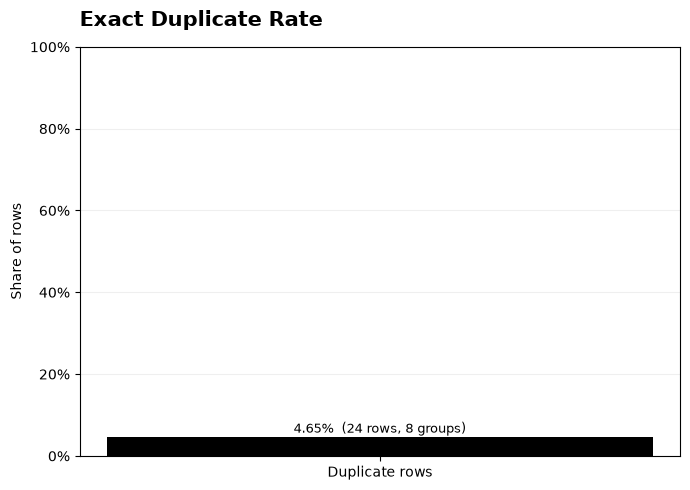

In [40]:
ed.plot.overview()

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'left': 'Largest Duplicate Groups'}, xlabel='Rows in group'>)

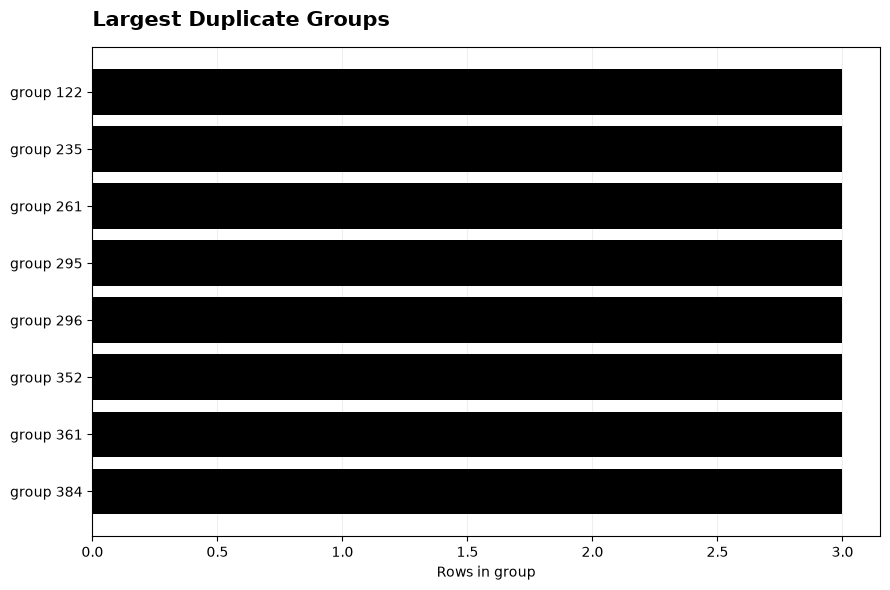

In [41]:
ed.plot.group_sizes()

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'left': 'Duplicate Groups: Label Consistency'}, ylabel='Number of duplicate groups'>)

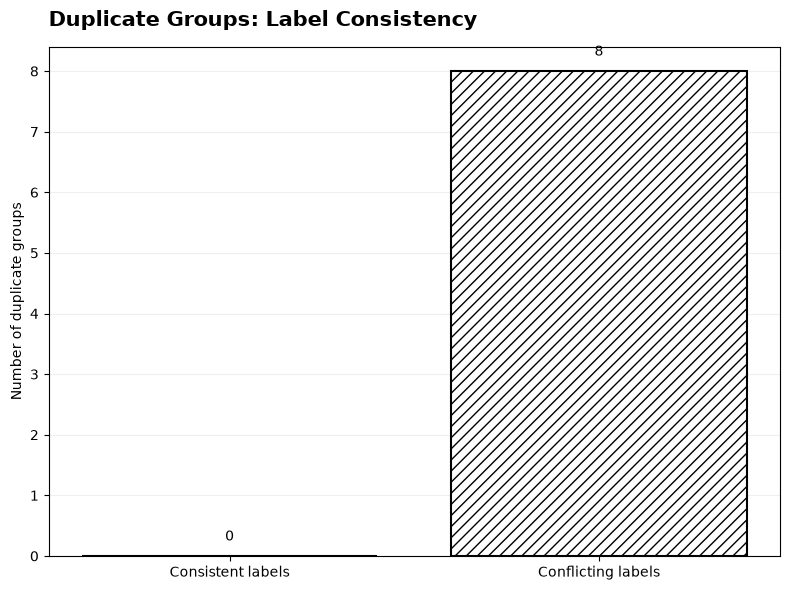

In [42]:
ed.plot.label_conflict_breakdown()